In [1]:
import os
from pathlib import Path

# Get the current directory of the notebook
notebook_path = Path.cwd()

ROOT = notebook_path.parent.parent

# Change the Working Directory for the whole process
os.chdir(ROOT)

print(f"Current Working Directory fixed to: {os.getcwd()}")

Current Working Directory fixed to: /srv/homes/onbo10/thesis_main


In [2]:
from src.Geometry.triangulation.triangulator import Triangulator
from src.Geometry.triangulation.keypoints_triangulation import run_triangulation_pipeline
from src.Keypoints_detection.inference.inferencer import keypointsDetectionInferencer
from src.Keypoints_detection.inference.inferencer import keypointsDetectionInferencer
import glob
import random
import yaml
from src.Keypoints_detection.training.utils import get_device
from types import SimpleNamespace
from hrnet_config import cfg , update_config
from src.Keypoints_detection.training.utils import load_pretrained_HRNet
from ultralytics import YOLO
from src.Keypoints_detection.Top_down_keypoints_detection_pipline import KeypointDetectionPipeline
from mmpose.apis import init_model
import numpy as np
#from utilities.visualizer import evaluate_MAE_and_compare
from src.Geometry.triangulation.triangulation_utils import *
from utilities.visualizer import TriangulationVisualizer

In [4]:
data_root_l='data/SurgPose/SurgPose_for_HRNet/Extracted' #'/srv/homes/onbo10/thesis_Ons/SurgePoseData/Extracted' 
data_root_r ='data/SurgPose/SurgPose_for_HRNet/Extracted_right_test' #'/srv/homes/onbo10/thesis_Ons/SurgePoseData/Extracted_right_test' 
split_file='data/SurgPose/SurgPose_for_HRNet/Extracted/video_split.yaml' #'/srv/homes/onbo10/thesis_Ons/SurgePoseData/Extracted/video_split.yaml' 
org_dataset_path =  'data/SurgPose/SurgPose_for_HRNet'#'/srv/homes/onbo10/thesis_Ons/SurgePoseData'

In [5]:
test_video_list, test_paths_l, test_paths_r = get_paths_and_video_lists(data_root_l, data_root_r, split_file)

Total images in directory: 11356
Images to process (Test Split): 2004


In [6]:
device = get_device()

In [7]:
det_model = YOLO("results/Keypoints_detection/training_results/YOLO_trainings/YOLO_Object_Experiment1/weights/best.pt")
det_model.eval();

+ Yolov8 + ViTpose

In [8]:

config_file = 'configs/Vitpose/vitpose_surg_7kpt.py'
checkpoint_file = 'results/Keypoints_detection/training_results/ViTpose_trainings/Experiment1/best_coco_AP_epoch_160.pth'
model_type_vitpose='vitpose'
pose_model_vitpose = init_model(config_file, checkpoint_file, device=device)
pose_model_vitpose.eval();

Loads checkpoint by local backend from path: results/Keypoints_detection/training_results/ViTpose_trainings/Experiment1/best_coco_AP_epoch_160.pth


In [9]:

vitpose_pipeline = KeypointDetectionPipeline(det_model,pose_model_vitpose,model_type_vitpose, device= device)


In [10]:

inferencer =  keypointsDetectionInferencer(vitpose_pipeline,'pipeline',device)


In [11]:

tri = Triangulator(num_keypoints=7)

In [12]:

# Run the pipeline
all_results_vitpose = run_triangulation_pipeline(
    inferencer=inferencer,
    triangulator=tri,
    test_paths_l=test_paths_l,
    test_paths_r=test_paths_r,
    test_video_list=test_video_list,
    org_dataset_path= org_dataset_path
)



Running batch inference on Test frames...
Processing Video: 000004
Processing Video: 000030
Processing Video: 000033
Processing Video: 000017
Processing Video: 000001
Processing Video: 000007


In [12]:
all_results_vitpose.keys()

dict_keys(['tri_3d', 'reproj_err_l', 'reproj_err_r', 'preds_l', 'preds_r', 'video_metadata'])

In [13]:
np.nanmean(all_results_vitpose['reproj_err_l'])

4.874445492290101

+ YOLO + HRNet (with aug)

In [28]:

# Load the pose model
cfg_file = 'configs/HRNet/w32_256x192_adam_lr1e-3__cropped_out7-finetune.yaml'
model_weights= 'results/Keypoints_detection/training_results/HRNet_trainings/Experiment3/training_checkpoints2026-03-02_23-16-42/model_epoch200.pth'

args = SimpleNamespace(
        cfg=cfg_file,
        opts=[],
        modelDir='',
        logDir='',
        dataDir='',
        prevModelDir=''
    )
update_config(cfg, args)
pose_model_hrnet= load_pretrained_HRNet(cfg, model_weights, finetuned=True)
device= get_device()
pose_model_hrnet.to(device)
pose_model_hrnet.eval()
model_type_hrnet='hrnet'


In [29]:
hrnet_pipeline = KeypointDetectionPipeline(det_model,pose_model_hrnet,model_type_hrnet, device= device)

In [30]:
hrnet_inferencer =  keypointsDetectionInferencer(hrnet_pipeline,'pipeline',device)


In [31]:

tri_hrnet = Triangulator(num_keypoints=7)

# Run the pipeline
all_results_hrnet = run_triangulation_pipeline(
    inferencer=hrnet_inferencer,
    triangulator=tri_hrnet,
    test_paths_l=test_paths_l,
    test_paths_r=test_paths_r,
    test_video_list=test_video_list,
    org_dataset_path= org_dataset_path
)



Running batch inference on Test frames...
Processing Video: 000004
Processing Video: 000030
Processing Video: 000033
Processing Video: 000017
Processing Video: 000001
Processing Video: 000007


In [19]:
hrnet_stats = calculate_success_metrics(all_results_hrnet)
vitpose_stats = calculate_success_metrics(all_results_vitpose)

In [20]:
hrnet_stats

{'Tool 0': {'Total Frames': 2004,
  'Successful Detections': 2004,
  'Success Rate (%)': 100.0},
 'Tool 1': {'Total Frames': 2004,
  'Successful Detections': 1996,
  'Success Rate (%)': 99.6}}

In [21]:
vitpose_stats

{'Tool 0': {'Total Frames': 2004,
  'Successful Detections': 2004,
  'Success Rate (%)': 100.0},
 'Tool 1': {'Total Frames': 2004,
  'Successful Detections': 1996,
  'Success Rate (%)': 99.6}}

In [22]:
samples_list= get_random_stereo_pairs(test_paths_l,test_paths_r,num_pairs= 10, seed= 50)

* Evaluation of Triangulation for ViTPose pipeline:

In [23]:
viz = TriangulationVisualizer(output_dir='results/Keypoints_detection/inference_results/triangulation/vitpose_pipeline')

/srv/homes/onbo10/thesis_main/utilities/visualizer.py:225: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=x_axis, y='Error (pixels)', data=df, inner="quartile", palette="muted")


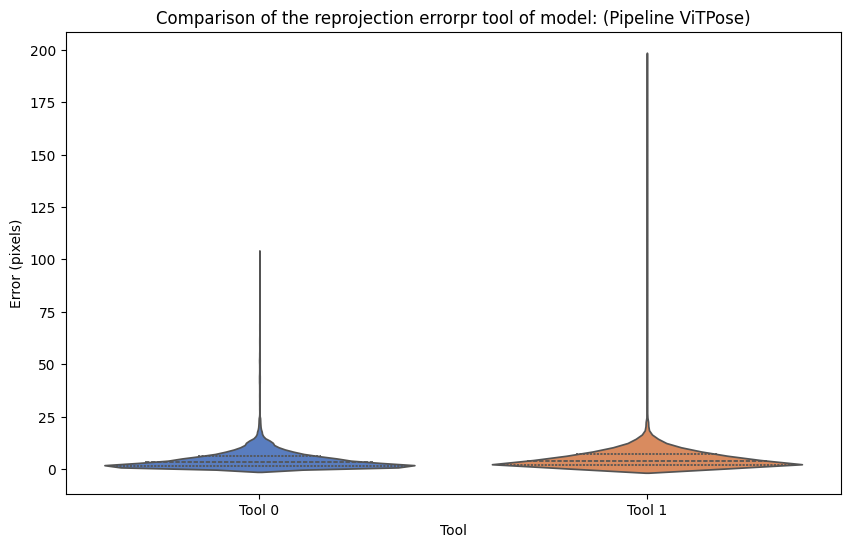

,mean,std,median,count
Tool,,,,
Tool 0,4.587,5.087,3.216,28056
Tool 1,5.333,6.673,4.032,27944


In [24]:
viz.reprojection_error_violin_plots(all_results_vitpose,model_names='Pipeline ViTPose')

In [25]:
for d in samples_list:

    left_img_list=[d['paths'][0]]
    right_img_list=[d['paths'][1]]
    video_id_list=[d['video_id']]
    single_pair_results = run_triangulation_pipeline(
        inferencer=inferencer,
        triangulator=tri,
        test_paths_l=left_img_list,
        test_paths_r=right_img_list,
        test_video_list=video_id_list,
        org_dataset_path= org_dataset_path
    )
    frame_name= os.path.basename(left_img_list[0]).split('.')[0]
    # Visualize
    
    viz.plot_reprojections(
        left_img_list[0], 
        right_img_list[0], 
        single_pair_results, 
        tri, 
        frame_name=frame_name
    )

Running batch inference on Test frames...
Processing Video: 000017
Running batch inference on Test frames...
Processing Video: 000033
Running batch inference on Test frames...
Processing Video: 000004
Running batch inference on Test frames...
Processing Video: 000007
Running batch inference on Test frames...
Processing Video: 000017
Running batch inference on Test frames...
Processing Video: 000033
Running batch inference on Test frames...
Processing Video: 000004
Running batch inference on Test frames...
Processing Video: 000030
Running batch inference on Test frames...
Processing Video: 000007
Running batch inference on Test frames...
Processing Video: 000030


In [26]:
for d in samples_list:

    left_img_list=[d['paths'][0]]
    right_img_list=[d['paths'][1]]
    video_id_list=[d['video_id']]
    single_pair_results = run_triangulation_pipeline(
        inferencer=inferencer,
        triangulator=tri,
        test_paths_l=left_img_list,
        test_paths_r=right_img_list,
        test_video_list=video_id_list,
        org_dataset_path= org_dataset_path
    )
    frame_name= os.path.basename(left_img_list[0]).split('.')[0]
    pts_3d= np.array(single_pair_results['tri_3d']).squeeze()
    # Visualize
    viz.plot_3d_tools(pts_3d,frame_name)

Running batch inference on Test frames...
Processing Video: 000017
Running batch inference on Test frames...
Processing Video: 000033
Running batch inference on Test frames...
Processing Video: 000004
Running batch inference on Test frames...
Processing Video: 000007
Running batch inference on Test frames...
Processing Video: 000017
Running batch inference on Test frames...
Processing Video: 000033
Running batch inference on Test frames...
Processing Video: 000004
Running batch inference on Test frames...
Processing Video: 000030
Running batch inference on Test frames...
Processing Video: 000007
Running batch inference on Test frames...
Processing Video: 000030


* Evaluation of Triangulation for HRNet pipeline:

In [11]:
viz_hrnet = TriangulationVisualizer(output_dir='results/Keypoints_detection/inference_results/triangulation/hrnet_aug_pipeline')

/srv/homes/onbo10/thesis_main/utilities/visualizer.py:225: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=x_axis, y='Error (pixels)', data=df, inner="quartile", palette="muted")


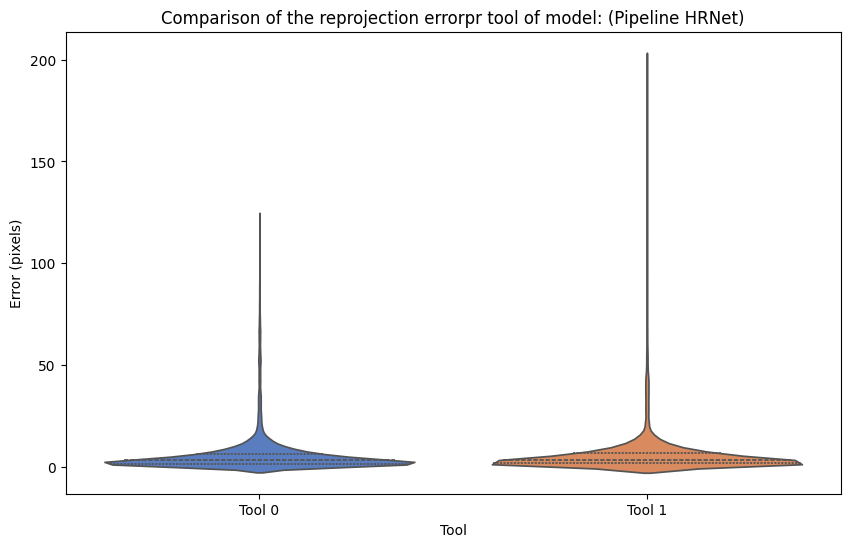

,mean,std,median,count
Tool,,,,
Tool 0,6.169,9.951,3.351,28056
Tool 1,6.309,10.575,3.688,27944


In [28]:
viz_hrnet.reprojection_error_violin_plots(all_results_hrnet,model_names='Pipeline HRNet')

In [29]:
for d in samples_list:

    left_img_list=[d['paths'][0]]
    right_img_list=[d['paths'][1]]
    video_id_list=[d['video_id']]
    single_pair_results = run_triangulation_pipeline(
        inferencer=hrnet_inferencer,
        triangulator=tri_hrnet,
        test_paths_l=left_img_list,
        test_paths_r=right_img_list,
        test_video_list=video_id_list,
        org_dataset_path= org_dataset_path
    )
    frame_name= os.path.basename(left_img_list[0]).split('.')[0]
    # Visualize
    
    viz_hrnet.plot_reprojections(
        left_img_list[0], 
        right_img_list[0], 
        single_pair_results, 
        tri_hrnet, 
        frame_name=frame_name
    )

Running batch inference on Test frames...
Processing Video: 000017
Running batch inference on Test frames...
Processing Video: 000033
Running batch inference on Test frames...
Processing Video: 000004
Running batch inference on Test frames...
Processing Video: 000007
Running batch inference on Test frames...
Processing Video: 000017
Running batch inference on Test frames...
Processing Video: 000033
Running batch inference on Test frames...
Processing Video: 000004
Running batch inference on Test frames...
Processing Video: 000030
Running batch inference on Test frames...
Processing Video: 000007
Running batch inference on Test frames...
Processing Video: 000030


In [30]:
for d in samples_list:

    left_img_list=[d['paths'][0]]
    right_img_list=[d['paths'][1]]
    video_id_list=[d['video_id']]
    single_pair_results = run_triangulation_pipeline(
        inferencer=inferencer,
        triangulator=tri_hrnet,
        test_paths_l=left_img_list,
        test_paths_r=right_img_list,
        test_video_list=video_id_list,
        org_dataset_path= org_dataset_path
    )
    frame_name= os.path.basename(left_img_list[0]).split('.')[0]
    pts_3d= np.array(single_pair_results['tri_3d']).squeeze()
    # Visualize
    viz_hrnet.plot_3d_tools(pts_3d,frame_name)

Running batch inference on Test frames...
Processing Video: 000017
Running batch inference on Test frames...
Processing Video: 000033
Running batch inference on Test frames...
Processing Video: 000004
Running batch inference on Test frames...
Processing Video: 000007
Running batch inference on Test frames...
Processing Video: 000017
Running batch inference on Test frames...
Processing Video: 000033
Running batch inference on Test frames...
Processing Video: 000004
Running batch inference on Test frames...
Processing Video: 000030
Running batch inference on Test frames...
Processing Video: 000007
Running batch inference on Test frames...
Processing Video: 000030


* Comparing both pipelines:

In [31]:
viz_comparison = TriangulationVisualizer(output_dir='results/Keypoints_detection/inference_results/triangulation/comparison')

/srv/homes/onbo10/thesis_main/utilities/visualizer.py:225: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=x_axis, y='Error (pixels)', data=df, inner="quartile", palette="muted")


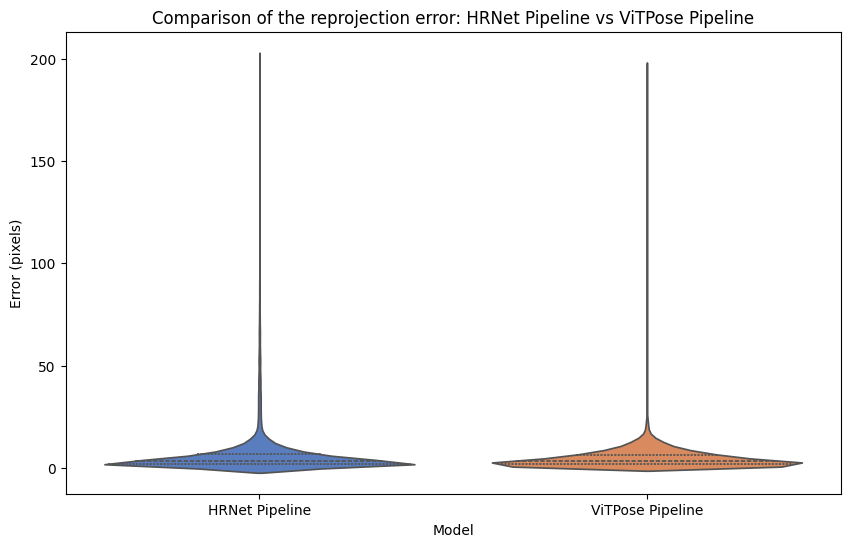

,mean,std,median,count
Model,,,,
HRNet Pipeline,6.239,10.267,3.506,56000
ViTPose Pipeline,4.959,5.943,3.619,56000


In [32]:
viz_comparison.reprojection_error_violin_plots([all_results_hrnet,all_results_vitpose], model_names=['HRNet Pipeline','ViTPose Pipeline'])

* Analyse some failure cases:

In [32]:

def get_failure_cases(results, error_threshold=15.0, top_k=5):
    failures = []
    
    # Shapes are  (2, 6, 334, 7)
    err_l_all = np.array(results['reproj_err_l']) 
    err_r_all = np.array(results['reproj_err_r'])
    
    num_tools, num_videos, num_frames, num_kpts = err_l_all.shape
    
    for t_idx in range(num_tools):
        for v_idx in range(num_videos):
            # errors shape: (334, 7)
            errors_l = err_l_all[t_idx, v_idx] 
            errors_r = err_r_all[t_idx, v_idx]
          
            
            combined = np.maximum(errors_l, errors_r)
            max_per_frame = np.nanmax(combined, axis=1)
                
            
            # Find frames in the current video taht are exceeding the threshold
            indices = indices = np.where(max_per_frame > error_threshold)[0]
            
            
            if indices.size > 0:
                for f_idx in indices:
                    failures.append({
                        'tool_idx': t_idx,
                        'video_idx': v_idx,
                        'frame_idx': int(f_idx),
                        'error': float(max_per_frame[f_idx])
                    })
            
    # Sort by the single float error value
    failures = sorted(failures, key=lambda x: x['error'], reverse=True)[:top_k]
   
    return failures

In [33]:
frames_per_video = 334
worst_cases = get_failure_cases(all_results_hrnet, error_threshold=50, top_k=-1)

# Initialize the list of lists
failure_path_pairs = []

for case in worst_cases:
    v = case['video_idx']
    f = case['frame_idx']
    
    # Calculate global index for flat list of 2004 items
    global_idx = (v * frames_per_video) + f
    
    # Safety check for index range
    if global_idx < len(test_paths_l):
        img_l_path = test_paths_l[global_idx]
        img_r_path = test_paths_r[global_idx]
        
        # Append the pair as a list
        failure_path_pairs.append([img_l_path, img_r_path, v])
        
        print(f"Added Pair - Video: {v}, Frame: {f}, Error: {case['error']:.2f}")
    else:
        print(f"Warning: Global index {global_idx} out of range for lists.")

# To see your result:
print(f"\nTotal pairs collected: {len(failure_path_pairs)}")

Added Pair - Video: 0, Frame: 163, Error: 200.61
Added Pair - Video: 0, Frame: 162, Error: 196.09
Added Pair - Video: 3, Frame: 26, Error: 149.25
Added Pair - Video: 5, Frame: 96, Error: 127.63
Added Pair - Video: 5, Frame: 295, Error: 125.16
Added Pair - Video: 3, Frame: 68, Error: 122.22
Added Pair - Video: 4, Frame: 147, Error: 117.07
Added Pair - Video: 5, Frame: 285, Error: 108.98
Added Pair - Video: 5, Frame: 100, Error: 106.44
Added Pair - Video: 4, Frame: 150, Error: 105.82
Added Pair - Video: 5, Frame: 265, Error: 103.94
Added Pair - Video: 5, Frame: 283, Error: 103.71
Added Pair - Video: 4, Frame: 134, Error: 102.89
Added Pair - Video: 1, Frame: 330, Error: 99.96
Added Pair - Video: 1, Frame: 40, Error: 98.37
Added Pair - Video: 5, Frame: 6, Error: 98.29
Added Pair - Video: 1, Frame: 329, Error: 96.95
Added Pair - Video: 1, Frame: 42, Error: 94.99
Added Pair - Video: 3, Frame: 32, Error: 94.59
Added Pair - Video: 5, Frame: 65, Error: 94.41
Added Pair - Video: 3, Frame: 25, Er

In [34]:
viz_failure = TriangulationVisualizer(output_dir='results/Keypoints_detection/inference_results/triangulation/failure/hrnet')

In [35]:
for pair in failure_path_pairs[:65]:

    left_img_list=[pair[0]]
    right_img_list=[pair[1]]
    video_id_list=[sorted(test_video_list)[pair[2]]]
    single_pair_results = run_triangulation_pipeline(
        inferencer=hrnet_inferencer,
        triangulator=tri_hrnet,
        test_paths_l=left_img_list,
        test_paths_r=right_img_list,
        test_video_list=video_id_list,
        org_dataset_path= org_dataset_path
    )
    frame_name= os.path.basename(left_img_list[0]).split('.')[0]
    # Visualize
    
    viz_failure.plot_reprojections(
        left_img_list[0], 
        right_img_list[0], 
        single_pair_results, 
        tri_hrnet, 
        frame_name=frame_name+'_hrnet'
    )

Running batch inference on Test frames...
Processing Video: 000001
Running batch inference on Test frames...
Processing Video: 000001
Running batch inference on Test frames...
Processing Video: 000017
Running batch inference on Test frames...
Processing Video: 000033
Running batch inference on Test frames...
Processing Video: 000033
Running batch inference on Test frames...
Processing Video: 000017
Running batch inference on Test frames...
Processing Video: 000030
Running batch inference on Test frames...
Processing Video: 000033
Running batch inference on Test frames...
Processing Video: 000033
Running batch inference on Test frames...
Processing Video: 000030
Running batch inference on Test frames...
Processing Video: 000033
Running batch inference on Test frames...
Processing Video: 000033
Running batch inference on Test frames...
Processing Video: 000030
Running batch inference on Test frames...
Processing Video: 000004
Running batch inference on Test frames...
Processing Video: 00